In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df_1 = pd.read_parquet("./dataset_1.parquet")
df_2 = pd.read_parquet("./dataset_2.parquet")
df_3 = pd.read_parquet("./dataset_3.parquet")

In [10]:
df_1.head()

,site_name,delivery_time,production,installed_capacity
0,Nobelwind Offshore Windpark,2022-12-31 23:00:00+00:00,162.7175,165.0
1,Nobelwind Offshore Windpark,2023-01-01 00:00:00+00:00,162.6850,165.0
2,Nobelwind Offshore Windpark,2023-01-01 01:00:00+00:00,162.6800,165.0
3,Nobelwind Offshore Windpark,2023-01-01 02:00:00+00:00,162.7300,165.0
4,Nobelwind Offshore Windpark,2023-01-01 03:00:00+00:00,162.7125,165.0


In [29]:
df_3.delivery_time.unique()

array(['2023-01-01 00:00:00+00:00', '2023-01-01 01:00:00+00:00',
       '2023-01-01 02:00:00+00:00', ..., '2026-02-20 21:00:00+00:00',
       '2026-02-20 22:00:00+00:00', '2026-02-20 23:00:00+00:00'],
      shape=(27528,), dtype=object)

In [30]:
df_1.delivery_time.unique()

<DatetimeArray>
['2022-12-31 23:00:00+00:00', '2023-01-01 00:00:00+00:00',
 '2023-01-01 01:00:00+00:00', '2023-01-01 02:00:00+00:00',
 '2023-01-01 03:00:00+00:00', '2023-01-01 04:00:00+00:00',
 '2023-01-01 05:00:00+00:00', '2023-01-01 06:00:00+00:00',
 '2023-01-01 07:00:00+00:00', '2023-01-01 08:00:00+00:00',
 ...
 '2026-02-18 13:00:00+00:00', '2026-02-18 14:00:00+00:00',
 '2026-02-18 15:00:00+00:00', '2026-02-18 16:00:00+00:00',
 '2026-02-18 17:00:00+00:00', '2026-02-18 18:00:00+00:00',
 '2026-02-18 19:00:00+00:00', '2026-02-18 20:00:00+00:00',
 '2026-02-18 21:00:00+00:00', '2026-02-18 22:00:00+00:00']
Length: 27480, dtype: datetime64[ns, UTC]

In [18]:
df_1.groupby('site_name')["installed_capacity"].value_counts()

site_name                         installed_capacity
Belwind Phase 1                   171.0                 27480
Mermaid Offshore WP               235.5                 27480
Nobelwind Offshore Windpark       165.0                 27480
Norther Offshore WP               369.6                 27480
Northwester 2                     219.1                 27480
Northwind                         216.0                 27480
Rentel Offshore WP                307.0                 27480
Seastar Offshore WP               252.0                 27480
Thorntonbank - C-Power - Area NE  147.6                 27480
Thorntonbank - C-Power - Area SW  177.6                 27480
Name: count, dtype: int64

In [21]:
df_1.isna().sum()

site_name              0
delivery_time          0
production            96
installed_capacity     0
dtype: int64

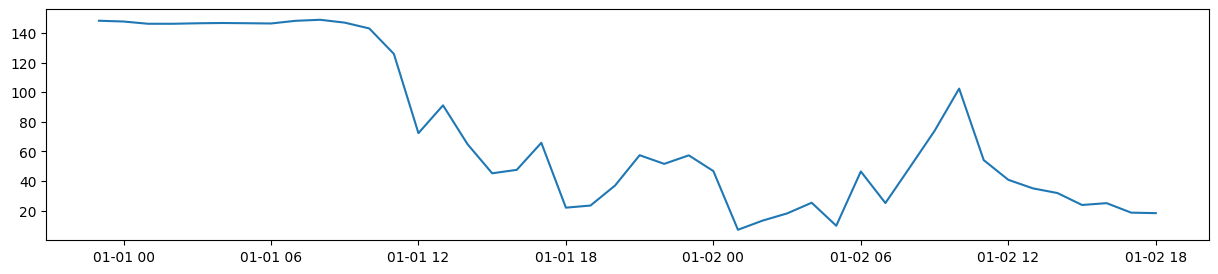

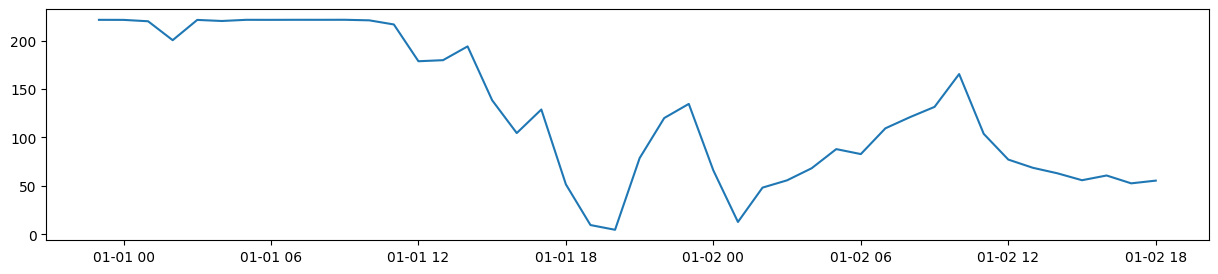

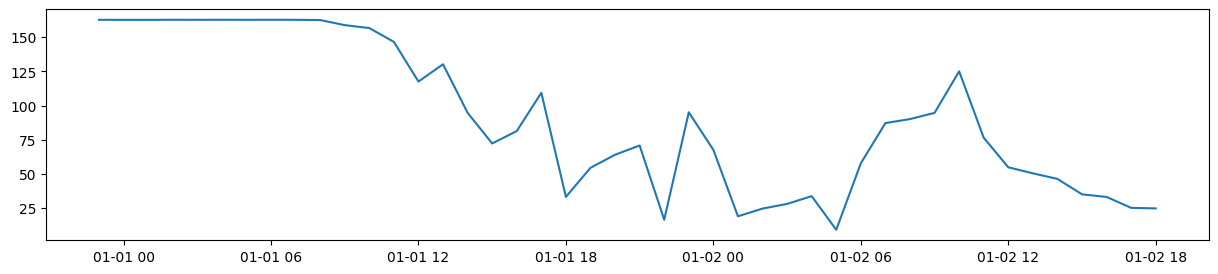

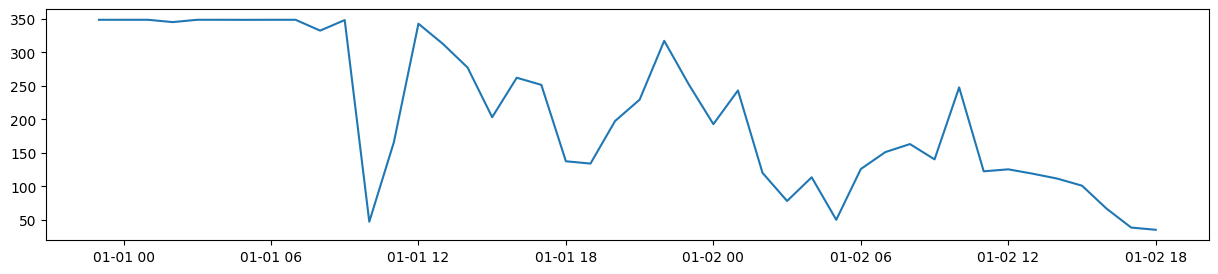

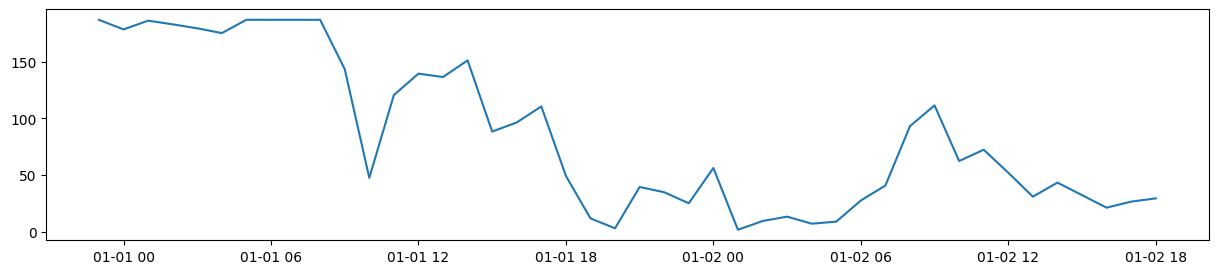

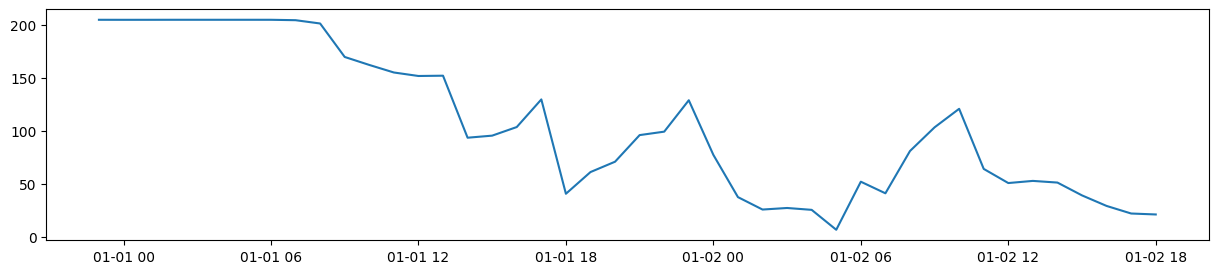

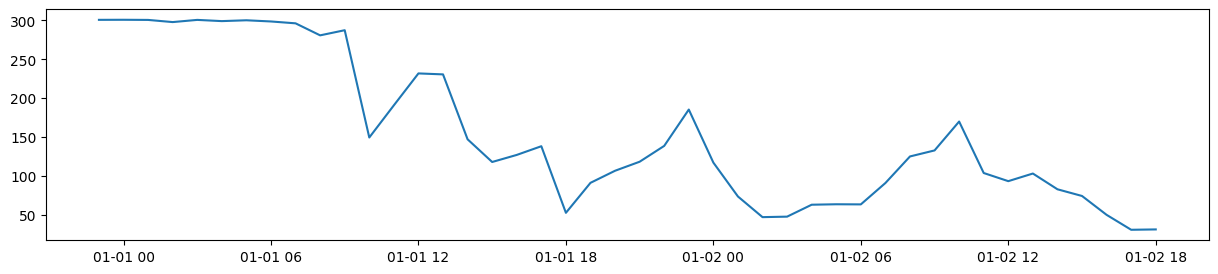

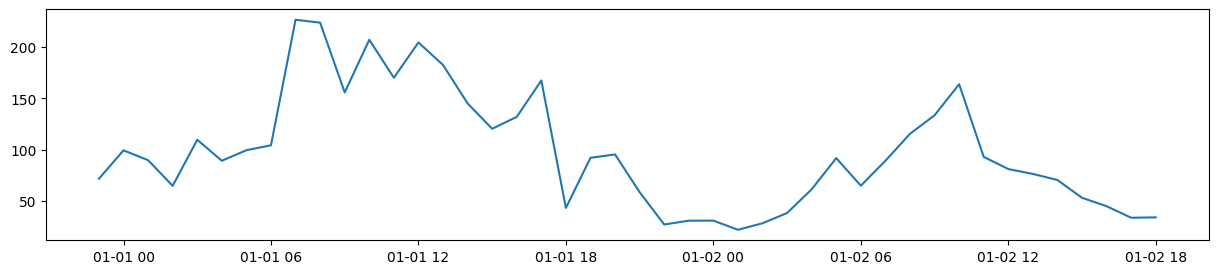

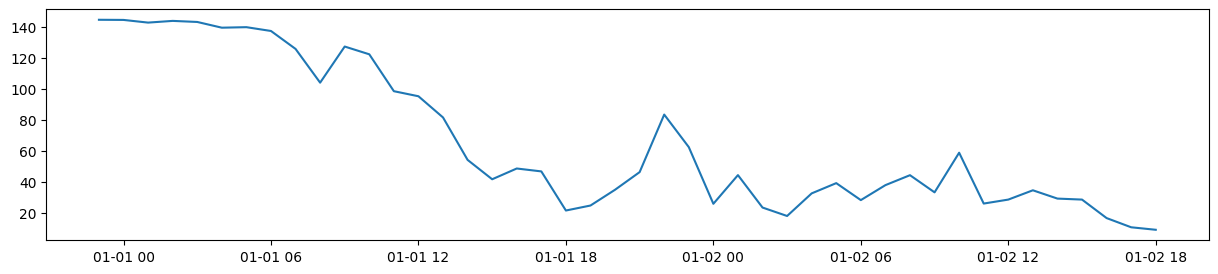

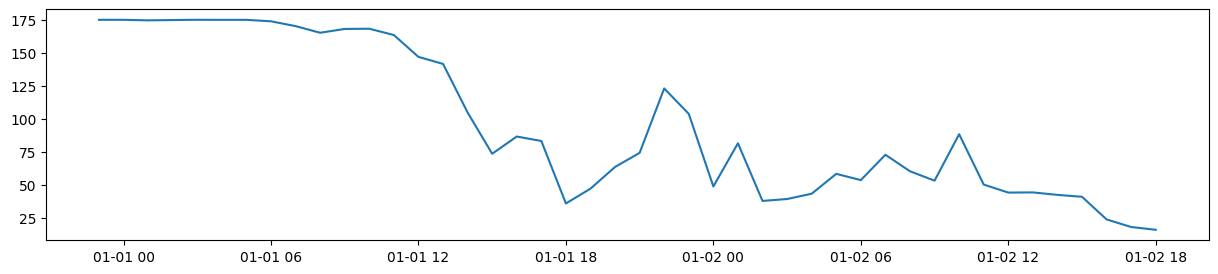

In [37]:
dict_series = {
    site: group.set_index('delivery_time')['production']
    for site, group in df_1.groupby('site_name')
}

for site in dict_series.keys():
    plt.figure(figsize=(15, 3))
    plt.plot(dict_series[site][:44])
    plt.show()


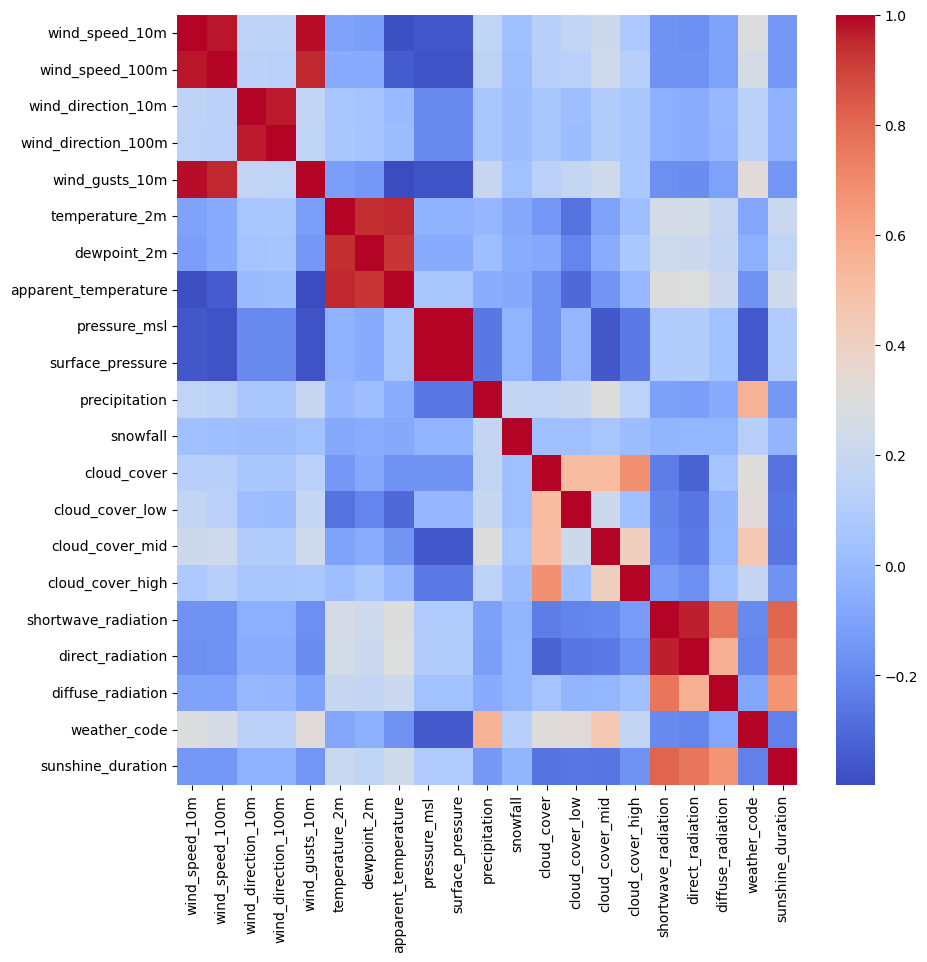

In [39]:
correlation_matrix = df_3.drop(columns=["site_name", "delivery_time"]).corr()

plt.figure(figsize=(10, 10))
sns.heatmap(correlation_matrix, cmap="coolwarm")
plt.show()